## Homework

> Note: sometimes your answer doesn't match one of 
> the options exactly. That's fine. 
> Select the option that's closest to your solution.

### Dataset

For this homework, we'll use the Car Fuel Efficiency dataset. Download it from <a href='https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv'>here</a>.

You can do it with wget:
```bash
wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv
```

The goal of this homework is to create a regression model for predicting the car fuel efficiency (column `'fuel_efficiency_mpg'`).

### Preparing the dataset 

Use only the following columns:

* `'engine_displacement'`,
* `'horsepower'`,
* `'vehicle_weight'`,
* `'model_year'`,
* `'fuel_efficiency_mpg'`

### EDA

* Look at the `fuel_efficiency_mpg` variable. Does it have a long tail? 

### Question 1

There's one column with missing values. What is it?

* `'engine_displacement'`
* **`'horsepower'`**
* `'vehicle_weight'`
* `'model_year'`

In [110]:
import pandas as pd
import seaborn as sns

In [111]:
df = pd.read_csv("../data/car_fuel_efficiency.csv", usecols=[
    "engine_displacement",
    "horsepower",
    "vehicle_weight",
    "model_year",
    "fuel_efficiency_mpg"
])

In [112]:
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

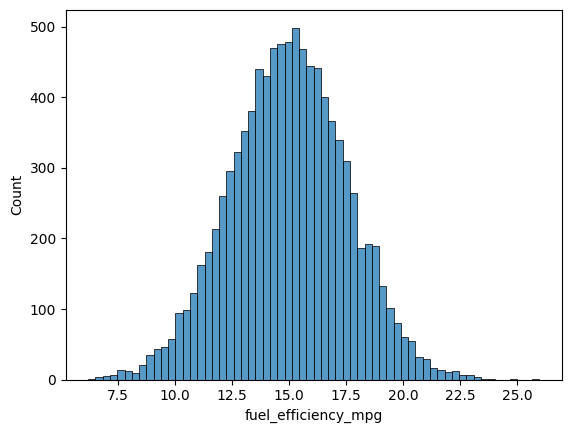

In [113]:
# Look at the `fuel_efficiency_mpg` variable. Does it have a long tail? 
# NO, It's a normal distribution
sns.histplot(df['fuel_efficiency_mpg'])


In [114]:
df.isna().sum()

engine_displacement      0
horsepower             708
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

### Question 2

What's the median (50% percentile) for variable `'horsepower'`?

- 49
- 99
- **149**
- 199

### Prepare and split the dataset

* Shuffle the dataset (the filtered one you created above), use seed `42`.
* Split your data in train/val/test sets, with 60%/20%/20% distribution.

Use the same code as in the lectures

In [115]:
df['horsepower'].median().astype('int')

np.int64(149)

In [116]:
import numpy as np

# Get the length of dataset
n = len(df)

# Calculate split sizes
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# Create index array and shuffle
idx = np.arange(n)
np.random.seed(42)  # Setting seed as required
np.random.shuffle(idx)

# Split the data
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

# Reset indices
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Get target variable
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

### Question 3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 2 decimal digits using `round(score, 2)`
* Which option gives better RMSE?

Options:

- With 0
- **With mean**
- Both are equally good

In [117]:
def rmse(y, y_pred):
    error = (y - y_pred) ** 2
    mse = error.mean()

    return np.sqrt(mse)


def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]


def prepare_X(df):
    X = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']].values
    return X

In [118]:
# Approach 1: Fill with 0
df_train_zero = df_train.copy()
df_val_zero = df_val.copy()
df_train_zero['horsepower'] = df_train_zero['horsepower'].fillna(0)
df_val_zero['horsepower'] = df_val_zero['horsepower'].fillna(0)

In [119]:
# Approach 2: Fill with mean from training
mean_horsepower = df_train['horsepower'].mean()
df_train_mean = df_train.copy()
df_val_mean = df_val.copy()
df_train_mean['horsepower'] = df_train_mean['horsepower'].fillna(mean_horsepower)
df_val_mean['horsepower'] = df_val_mean['horsepower'].fillna(mean_horsepower)

In [120]:
# Train and evaluate model with zeros
X_train_zero = prepare_X(df_train_zero)
w0_zero, w_zero = train_linear_regression(X_train_zero, y_train)

X_val_zero = prepare_X(df_val_zero)
y_pred_zero = w0_zero + X_val_zero.dot(w_zero)
rmse_zero = round(np.sqrt(rmse(y_val, y_pred_zero)), 2)

In [121]:
# Train and evaluate model with mean
X_train_mean = prepare_X(df_train_mean)
w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)

X_val_mean = prepare_X(df_val_mean)
y_pred_mean = w0_mean + X_val_mean.dot(w_mean)
rmse_mean = round(np.sqrt(rmse(y_val, y_pred_mean)), 2)

In [122]:
print(f'RMSE with zeros: {rmse_zero}')
print(f'RMSE with mean: {rmse_mean}')

RMSE with zeros: 0.72
RMSE with mean: 0.68


### Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 2 decimal digits.
* Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.

Options:

- 0
- **0.01**
- 1
- 10
- 100

In [123]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [124]:
# Prepare data with zeros for missing values
df_train_zero = df_train.copy()
df_val_zero = df_val.copy()
df_train_zero['horsepower'] = df_train_zero['horsepower'].fillna(0)
df_val_zero['horsepower'] = df_val_zero['horsepower'].fillna(0)

In [125]:
# Prepare features
X_train = prepare_X(df_train_zero)
X_val = prepare_X(df_val_zero)

In [126]:
r_values = [0, 0.01, 0.1, 1, 5, 10, 100]
rmse_scores = {}

for r in r_values:
    # Train model
    w0, w = train_linear_regression_reg(X_train, y_train, r)
    
    # Make predictions
    y_pred = w0 + X_val.dot(w)
    
    # Calculate RMSE
    rmse_score = np.sqrt(rmse(y_val, y_pred))
    rmse_scores[r] = rmse_score
    print(f'r={r}, RMSE={rmse_score}')

r=0, RMSE=0.7192901110707456
r=0.01, RMSE=0.7191046881895952
r=0.1, RMSE=0.7202447591410226
r=1, RMSE=0.7226582042772776
r=5, RMSE=0.7231124458079483
r=10, RMSE=0.7231744588712018
r=100, RMSE=0.7232313761044893


In [127]:
best_r = min([r for r in r_values if rmse_scores[r] == min(rmse_scores.values())])
print(f'\nBest r value: {best_r} (RMSE={rmse_scores[best_r]})')


Best r value: 0.01 (RMSE=0.7191046881895952)


### Question 5 

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

- 0.001
- **0.006**
- 0.060
- 0.600

> Note: Standard deviation shows how different the values are.
> If it's low, then all values are approximately the same.
> If it's high, the values are different. 
> If standard deviation of scores is low, then our model is *stable*.

In [128]:
def calculate_rmse_for_seed(seed, df):
    # Split the data
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test
    
    # Create index array and shuffle
    idx = np.arange(n)
    np.random.seed(seed)
    np.random.shuffle(idx)
    
    # Split into train/val/test
    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
    
    # Fill missing values with 0
    df_train_zero = df_train.copy()
    df_val_zero = df_val.copy()
    df_train_zero['horsepower'] = df_train_zero['horsepower'].fillna(0)
    df_val_zero['horsepower'] = df_val_zero['horsepower'].fillna(0)
    
    # Prepare features and target
    X_train = prepare_X(df_train_zero)
    X_val = prepare_X(df_val_zero)
    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    
    # Train model and make predictions
    w0, w = train_linear_regression(X_train, y_train)
    y_pred = w0 + X_val.dot(w)
    
    # Calculate RMSE
    return np.sqrt(rmse(y_val, y_pred))

In [129]:
# Calculate RMSE for each seed
seeds = list(range(10))  # [0,1,2,3,4,5,6,7,8,9]
rmse_scores = []

for seed in seeds:
    rmse_score = calculate_rmse_for_seed(seed, df)
    rmse_scores.append(rmse_score)
    print(f'Seed {seed}, RMSE: {rmse_score:.3f}')

Seed 0, RMSE: 0.722
Seed 1, RMSE: 0.722
Seed 2, RMSE: 0.723
Seed 3, RMSE: 0.718
Seed 4, RMSE: 0.715
Seed 5, RMSE: 0.727
Seed 6, RMSE: 0.729
Seed 7, RMSE: 0.713
Seed 8, RMSE: 0.717
Seed 9, RMSE: 0.716


In [130]:
# Calculate standard deviation
std = round(np.std(rmse_scores), 3)
print(f'\nStandard deviation of RMSE scores: {std}')


Standard deviation of RMSE scores: 0.005


### Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`. 
* What's the RMSE on the test dataset?

Options:

- 0.15
- **0.515**
- 5.15
- 51.5

In [132]:
# Get the length of dataset and set seed
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

# Create index array and shuffle with seed 9
idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)

# Split the data
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

# Combine train and validation sets
df_train_val = pd.concat([df_train, df_val])
df_train_val = df_train_val.reset_index(drop=True)

# Fill missing values with 0
df_train_val['horsepower'] = df_train_val['horsepower'].fillna(0)
df_test['horsepower'] = df_test['horsepower'].fillna(0)

# Prepare features
X_train_val = prepare_X(df_train_val)
X_test = prepare_X(df_test)

# Prepare target
y_train_val = df_train_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

# Train model with r=0.001
w0, w = train_linear_regression_reg(X_train_val, y_train_val, r=0.001)

# Make predictions
y_pred = w0 + X_test.dot(w)

# Calculate final RMSE
final_rmse = rmse(y_test, y_pred)
print(f'Final RMSE on test: {final_rmse:.3f}')

Final RMSE on test: 0.516


/var/folders/cf/yvx1ty9x60zg9rmfrmvm7pyc0000gn/T/ipykernel_83578/727812061.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test['horsepower'] = df_test['horsepower'].fillna(0)
